Data Preparation: Before building a model, you must handle the "messy" parts of the Titanic data. You will
need pandas, sklearn.tree, sklearn.ensemble, and sklearn.metrics.
a. Download the data into a clean jupyter notebook:
https://www.kaggle.com/datasets/sakshisatre/titanic-dataset/data
b. Start with some preliminary data exploration (at least 4 graphs needed here!). How will you handle
the missing values in the Age column, and how will you convert the categorical Sex column into a
numerical format that a Decision Tree can understand?
2. The Initial Split: Split your data into a training set and a testing set (typically 80/20). Why is it important to
use a random_state parameter when performing this split?
3. Training the Tree: Look up the parameters of the DecisionTreeClassifier. Initialize a
DecisionTreeClassifier and fit it to your training data. At this stage, do not set any limits on the depth of the
tree. Once trained, calculate the accuracy on the training set vs. the test set. If the training accuracy is 100%
but the test accuracy is 70%, what has happened to your model?
4. Visualizing the Logic: Use plot_tree from Scikit-Learn to look at the first three levels of your tree. Which
feature did the model choose for the very first "split" at the top (the root node)? Based on Titanic history,
does this split make logical sense to you?
5. Pruning for Health: Re-train the model, but this time set max_depth=3. Compare the test accuracy of this
"shorter" tree to your previous deep tree. Why does limiting the tree's growth often improve performance
on the test set?
6. Growing the Forest: Now, initialize a RandomForestClassifier with 100 trees (n_estimators=100). Train it
on the same data. In your own words, how is the way this forest makes a prediction different from the
single tree you built in Question 3?
7. Investigating Errors (Type I vs Type II): Generate a Confusion Matrix for your Random Forest predictions.
How many passengers did the model predict would survive who actually died (False Positives), and how
many did it predict would die who actually survived (False Negatives)?
8. The Tradeoff: Calculate the Precision and Recall. If you were a rescue coordinator and your goal was to
"leave no one behind" (ensure every survivor is found), would you be more concerned with maximizing
Precision or Recall?
9. Measuring Discrimination (ROC AUC): Plot the ROC Curve and calculate the AUC score for your
Random Forest. If your AUC is 0.85, what does that tell you about the model’s ability to distinguish
between a survivor and a victim compared to a random coin flip?
10. Feature Importance: The Random Forest has an attribute called feature_importances_. Extract these values
and create a small bar chart. Which three features were the most "influential" in the forest's decision-
making process? Did the model find any feature to be completely useless?


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
df = pd.read_csv("Titanic Dataset.csv")
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import RocCurveDisplay

In [3]:
print(df.head())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis, MO  


In [32]:
df.nlargest(10, 'age')

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
14,1,1,"Barkworth, Mr. Algernon Henry Wilson",1,80.0,0,0,27042,30.0000,A23,S,B,NaN,"Hessle, Yorks"
61,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",0,76.0,1,0,19877,78.8500,C46,S,6,NaN,"Little Onn Hall, Staffs"
1235,3,0,"Svensson, Mr. Johan",1,74.0,0,0,347060,7.7750,NaN,S,NaN,NaN,NaN
9,1,0,"Artagaveytia, Mr. Ramon",1,71.0,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"
135,1,0,"Goldschmidt, Mr. George B",1,71.0,0,0,PC 17754,34.6542,A5,C,NaN,NaN,"New York, NY"
727,3,0,"Connors, Mr. Patrick",1,70.5,0,0,370369,7.7500,NaN,Q,NaN,171.0,NaN
81,1,0,"Crosby, Capt. Edward Gifford",1,70.0,1,1,WE/P 5735,71.0000,B22,S,NaN,269.0,"Milwaukee, WI"
506,2,0,"Mitchell, Mr. Henry Michael",1,70.0,0,0,C.A. 24580,10.5000,NaN,S,NaN,NaN,"Guernsey / Montclair, NJ and/or Toledo, Ohio"
285,1,0,"Straus, Mr. Isidor",1,67.0,1,0,PC 17483,221.7792,C55 C57,S,NaN,96.0,"New York, NY"
594,2,0,"Wheadon, Mr. Edward H",1,66.0,0,0,C.A. 24579,10.5000,NaN,S,NaN,NaN,"Guernsey, England / Edgewood, RI"


In [30]:
df_cut=df.dropna(subset = ['age'])

In [31]:
df_cut

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,3,0,"Youseff, Mr. Gerious",1,45.50,0,0,2628,7.2250,NaN,C,NaN,312.0,NaN
1304,3,0,"Zabour, Miss. Hileni",0,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",1,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",1,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [28]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0}) 

In [29]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",0,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",0,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",1,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",1,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [34]:
df_y = df['survived']
df_X = df[['sex','age','pclass','sibsp']]

In [38]:
Xtest, Xtrain, ytest, ytrain = train_test_split(df_X, df_y, test_size=0.2, random_state=1)

In [39]:
model1=DecisionTreeClassifier()

In [46]:
model1.fit(Xtrain,ytrain)
ypred=model1.predict(Xtest)

In [54]:
accuracy_score(ytest,ypred)

0.7602674307545367

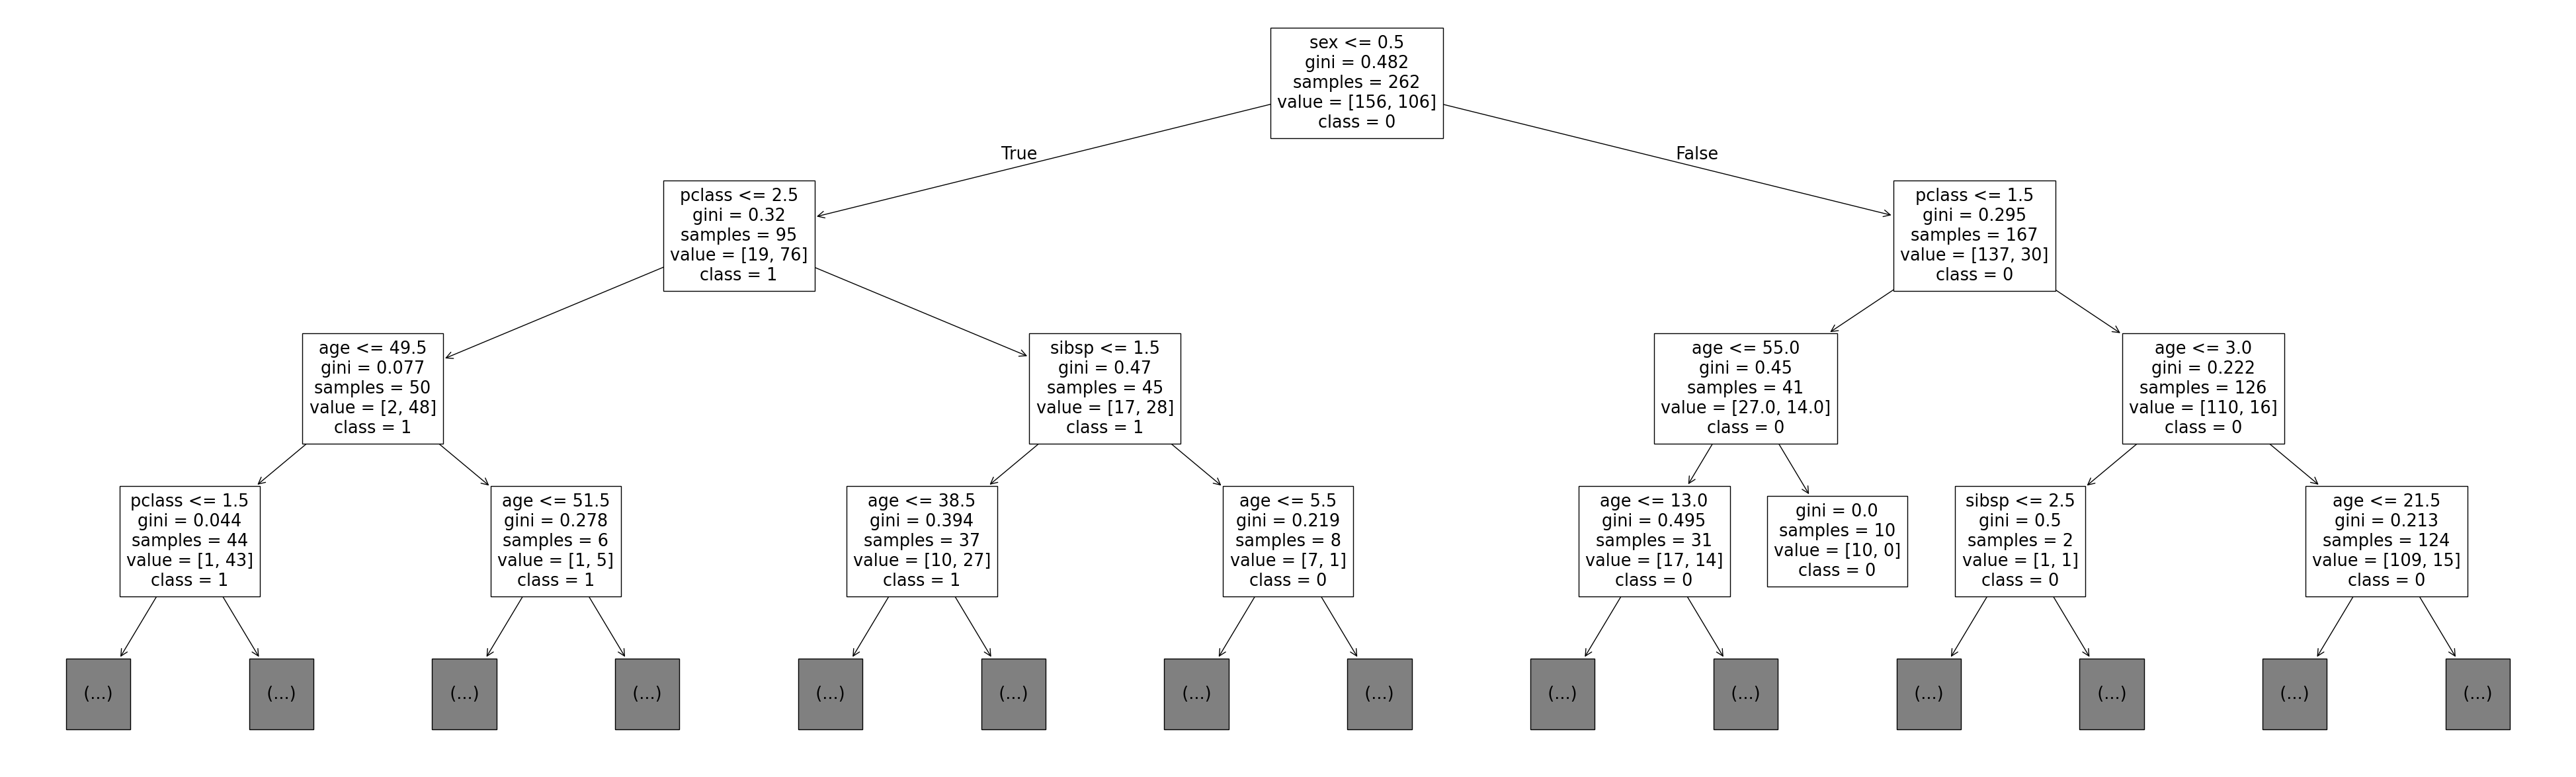

In [75]:
plt.figure(figsize=(50, 15))
plot_tree(model1,feature_names=['sex','age','pclass','sibsp'],class_names=['0','1'],max_depth=3)
plt.show()
#Choosing sex for the first split makes sense, since at the time sexism was extremely rampant, and there was likely bias for men, allowing
#them to survive more frequently possibly

In [76]:
model2=DecisionTreeClassifier(max_depth=3)
model2.fit(Xtrain,ytrain)
ypred2=model2.predict(Xtest)
accuracy_score(ytest,ypred2)
#I think that the higher accuracy with less depth is because the model becomes 
#less specific to its exact training values, and can actually be more accurate by not being dependent on what it trained with.

0.7793696275071633

In [78]:
model3=RandomForestClassifier(n_estimators=100)
model3.fit(Xtrain,ytrain)
ypred3=model3.predict(Xtest)
accuracy_score(ytest,ypred3)
#This forest makes a prediction based on the 'majority vote' of the predictions that each tree would make, which makes it more likely to
#pick the correct option than just one tree, who only chooses based on its own training.

0.7621776504297995

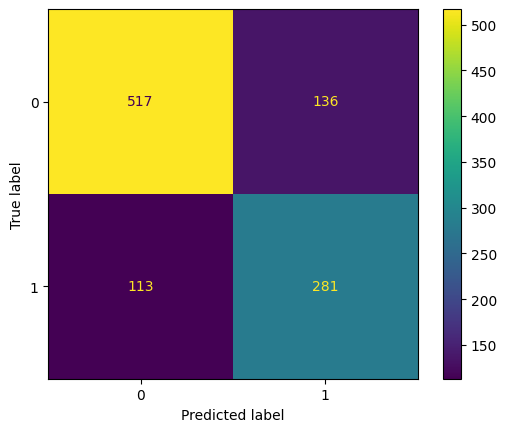

In [80]:
cm = confusion_matrix(ytest,ypred3)

display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.show()

In [83]:
recall_score(ytest,ypred3)

0.7131979695431472

In [84]:
precision_score(ytest,ypred3)

0.6738609112709832

In [86]:
#if I were trying to save the most people, I would want to minimize false negatives and be okay with more false positives. So, I would want
#my recall to be higher, so that I catch the most true positives that I can.

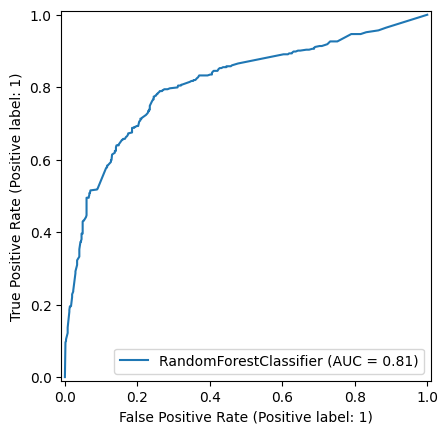

In [90]:
RocCurveDisplay.from_estimator(model3, Xtest, ytest)
plt.show()

In [92]:
roc_auc_score(ytest,ypred3)
#This tells me that the model is not coinflipping, and is choosing accurately 75% percent of the time.

0.7524642221375766

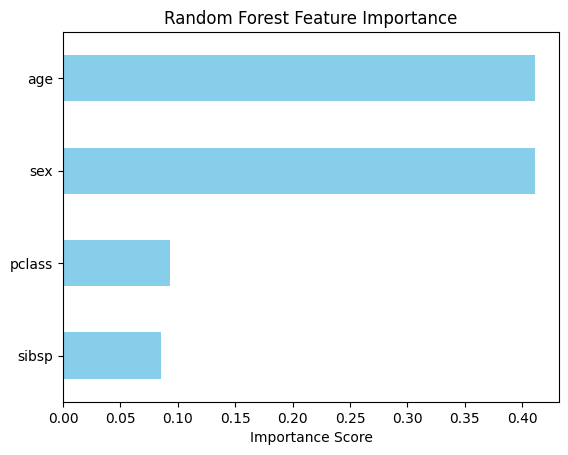

In [94]:
importances = model3.feature_importances_
feature_names = Xtrain.columns
feat_importances = pd.Series(importances, index=feature_names)
feat_importances = feat_importances.sort_values(ascending=True) 
feat_importances.plot(kind='barh', color='skyblue')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [95]:
#age and sex seem to have a very strong impact for deciding survival or not, which makes sense.